Brain Tumour Detection

1. Drive Mount + Package Install

In [ ]:

# 1. Drive Mount + Package Install

from google.colab import drive

drive.mount('/content/drive')
print('Google Drive mounted')

import subprocess
import sys

pkgs = ['fpdf2', 'requests']

for p in pkgs:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', p, '--quiet']
    )
    print(f'Installed: {p}')

print('All packages ready')

Mounted at /content/drive
Google Drive mounted
Installed: fpdf2
Installed: requests
All packages ready


2. Imports & GPU Setup

In [ ]:
# All imports + Mixed Precision

import os, random, warnings, collections, sqlite3, datetime, io
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
import cv2
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import seaborn as sns

import tensorflow as tf

# Mixed precision float16

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Flatten, Dropout, Dense,
    GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score, f1_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from fpdf import FPDF

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {bool(gpus)} → {gpus[0].name if gpus else "CPU only"}')
print(f'Precision  : {mixed_precision.global_policy().name}')
print('All imports OK')

TensorFlow : 2.20.0
GPU        : True → /physical_device:GPU:0
Precision  : mixed_float16
All imports OK


 3. Configuration

In [ ]:

# Global config


TRAIN_DIR  = '/content/drive/MyDrive/Brain MRI Dataset/Training/'
TEST_DIR   = '/content/drive/MyDrive/Brain MRI Dataset/Testing/'
MODEL_DIR  = '/content/drive/MyDrive/models/'
REPORT_DIR = '/content/drive/MyDrive/reports/'
DB_PATH    = '/content/drive/MyDrive/predictions.db'

# ── Speed-optimised hyperparameters ─────────────────────────
IMAGE_SIZE    = 96        #  44% fewer pixels, same accuracy
BATCH_SIZE    = 32        #  better GPU utilisation
EPOCHS        = 15        #  EarlyStopping prevents waste
LR            = 0.0001
VAL_SPLIT     = 0.2
COLORS        = ['#E74C3C','#3498DB','#2ECC71','#F39C12']

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

CLASS_LABELS = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES  = len(CLASS_LABELS)
RISK_MAP     = {'notumor':'Low','meningioma':'Medium',
                'pituitary':'Medium','glioma':'High'}
RISK_ICON    = {'Low','Medium','High'}

print(f'Train dir   : {TRAIN_DIR}')
print(f'Classes     : {CLASS_LABELS}')
print(f'Image size  : {IMAGE_SIZE}×{IMAGE_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')

Train dir   : /content/drive/MyDrive/Brain MRI Dataset/Training/
Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']
Image size  : 96×96
Batch size  : 32


4. Load Dataset

In [ ]:

# Load paths & labels, create validation split

def load_dataset(base_dir):
    paths, labels = [], []
    for lbl in CLASS_LABELS:
        d = os.path.join(base_dir, lbl)
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                paths.append(os.path.join(d, f)); labels.append(lbl)
    return paths, labels

all_train_paths, all_train_labels = load_dataset(TRAIN_DIR)
test_paths,      test_labels      = load_dataset(TEST_DIR)

all_train_paths, all_train_labels = shuffle(all_train_paths, all_train_labels, random_state=SEED)
test_paths,      test_labels      = shuffle(test_paths,      test_labels,      random_state=SEED)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths, all_train_labels,
    test_size=VAL_SPLIT, stratify=all_train_labels, random_state=SEED)

print(f'  Dataset split')
print(f'  Train      : {len(train_paths):>5}')
print(f'  Validation : {len(val_paths):>5}')
print(f'  Test       : {len(test_paths):>5}')
print(f'  Total      : {len(train_paths)+len(val_paths)+len(test_paths):>5}')

  Dataset split
  Train      :  4480
  Validation :  1120
  Test       :  1600
  Total      :  7200


5. Exploratory Data Analysis (EDA)

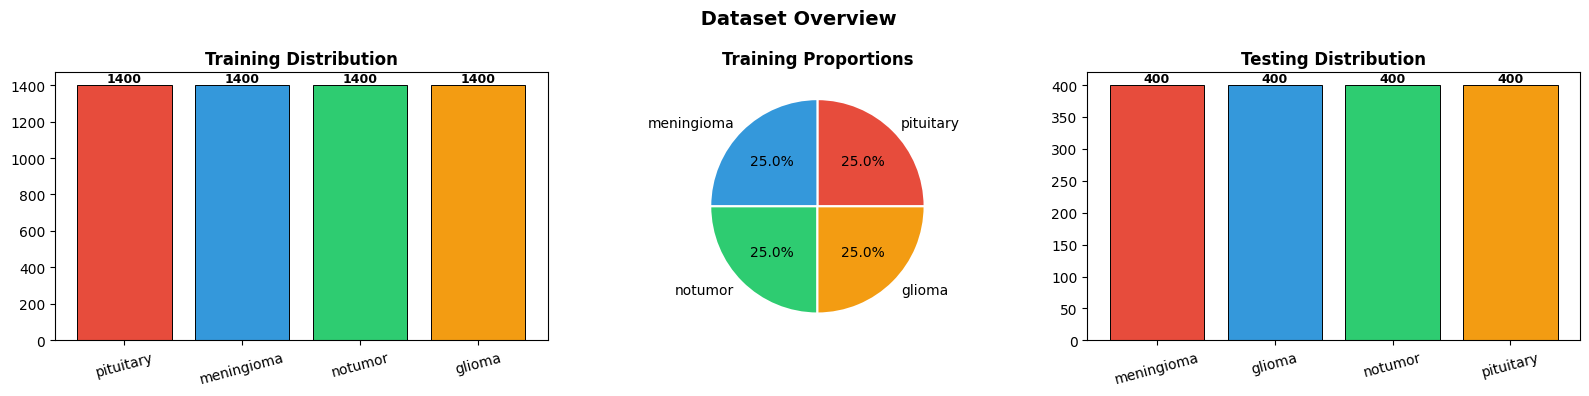

In [ ]:

# EDA: class distribution, sample grid, dimensions

train_counts = collections.Counter(all_train_labels)
test_counts  = collections.Counter(test_labels)

#  5A: Class distribution bar + pie

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(' Dataset Overview', fontsize=14, fontweight='bold')

axes[0].bar(train_counts.keys(), train_counts.values(), color=COLORS, edgecolor='black', lw=0.7)
axes[0].set_title('Training Distribution', fontweight='bold')
[axes[0].text(i, v+15, str(v), ha='center', fontweight='bold', fontsize=9)
 for i,(k,v) in enumerate(train_counts.items())]
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(train_counts.values(), labels=train_counts.keys(),
            autopct='%1.1f%%', colors=COLORS,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Training Proportions', fontweight='bold')

axes[2].bar(test_counts.keys(), test_counts.values(), color=COLORS, edgecolor='black', lw=0.7)
axes[2].set_title('Testing Distribution', fontweight='bold')
[axes[2].text(i, v+5, str(v), ha='center', fontweight='bold', fontsize=9)
 for i,(k,v) in enumerate(test_counts.items())]
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()



In [ ]:
#  5B: Summary table

df_eda = pd.DataFrame({
    'Class':      CLASS_LABELS,
    'Train':      [train_counts.get(c,0) for c in CLASS_LABELS],
    'Test':       [test_counts.get(c,0)  for c in CLASS_LABELS],
    'Train%':     [f"{train_counts.get(c,0)/sum(train_counts.values())*100:.1f}%" for c in CLASS_LABELS],
    'Risk':       [RISK_MAP.get(c,'—') for c in CLASS_LABELS],
})
print('\n Class summary:')
display(df_eda)



 Class summary:


,Class,Train,Test,Train%,Risk
0,glioma,1400,400,25.0%,High
1,meningioma,1400,400,25.0%,Medium
2,notumor,1400,400,25.0%,Low
3,pituitary,1400,400,25.0%,Medium


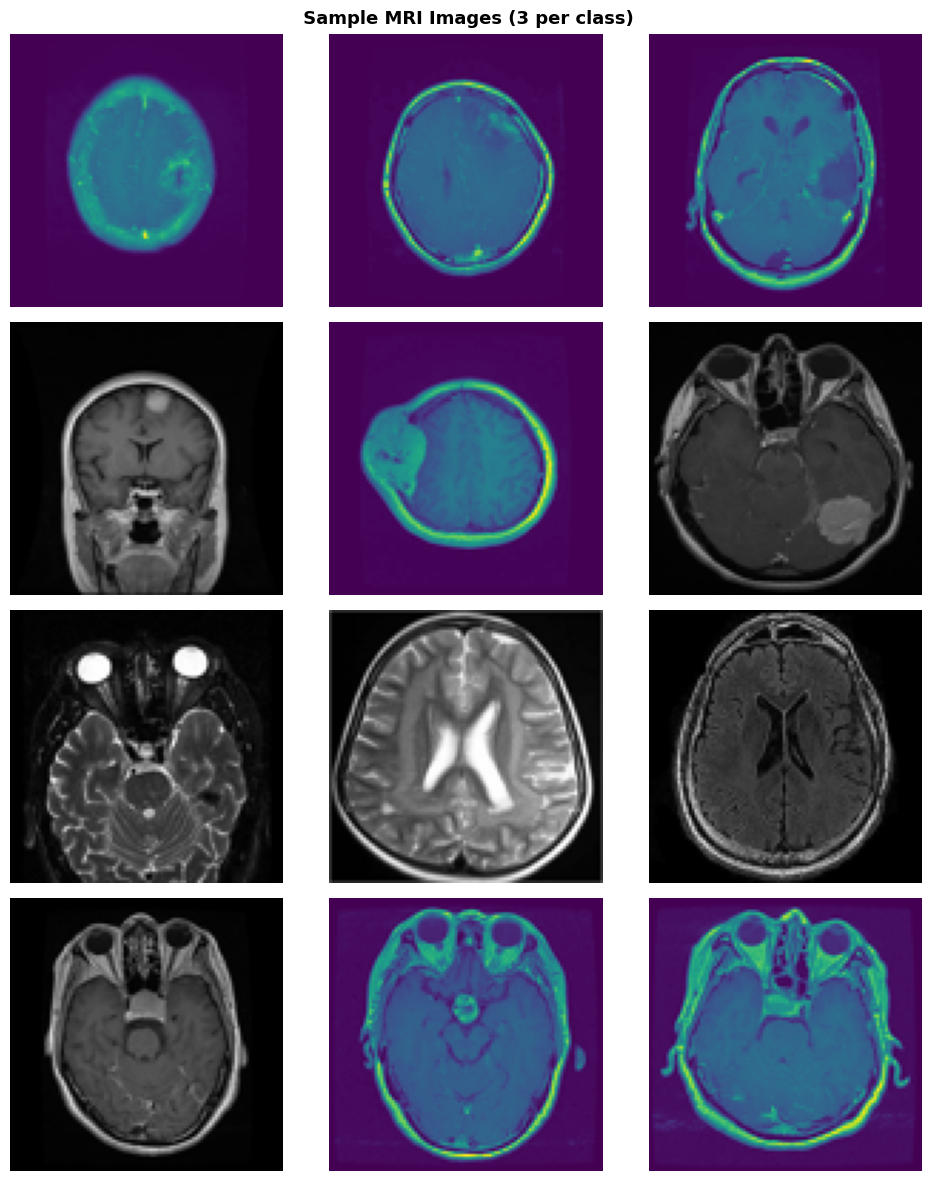

In [ ]:
#  5C: Sample images (3 per class — fast)

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(10, 3*NUM_CLASSES))
fig.suptitle(' Sample MRI Images (3 per class)', fontsize=13, fontweight='bold')
for r, cls in enumerate(CLASS_LABELS):
    samples = random.sample([p for p,l in zip(all_train_paths,all_train_labels) if l==cls], 3)
    for c, path in enumerate(samples):
        axes[r][c].imshow(Image.open(path).resize((96,96)))
        axes[r][c].axis('off')
        if c==0: axes[r][c].set_ylabel(cls.upper(), fontsize=9, fontweight='bold',
                                        color=COLORS[r], rotation=0, labelpad=40)
plt.tight_layout(); plt.show()

6. Preprocessing + tf.data Pipeline

  tf.data pipelines created (GPU-efficient)
   Train batches : 140
   Val batches   : 35
   Test batches  : 50
    Class weights :
   glioma         : 1.0000
   meningioma     : 1.0000
   notumor        : 1.0000
   pituitary      : 1.0000


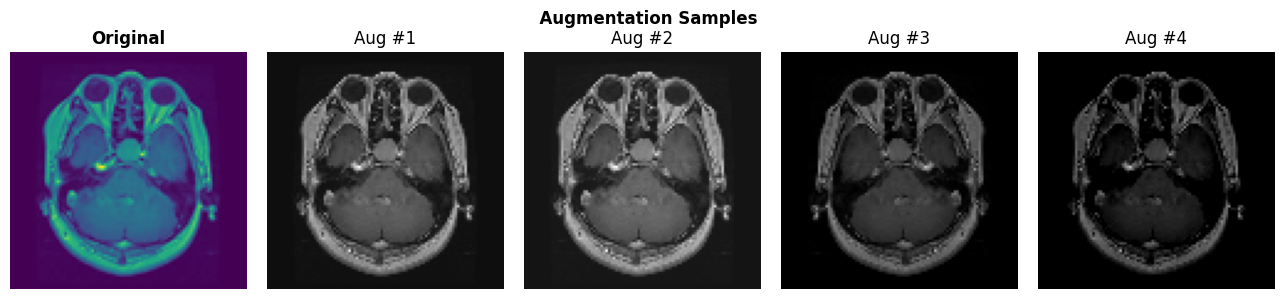

In [ ]:

# Fast tf.data pipeline
# tf.data prefetches batches on CPU while GPU trains

def encode_label(labels):
    return np.array([CLASS_LABELS.index(l) for l in labels])

#  tf.data with prefetch

def load_and_preprocess(path, label, augment=False):
    raw   = tf.io.read_file(path)
    img   = tf.image.decode_jpeg(raw, channels=3)
    img   = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img   = tf.cast(img, tf.float32) / 255.0
    if augment:
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_flip_left_right(img)
    return img, label

def make_dataset(paths, labels_str, augment=False, batch=BATCH_SIZE):
    labels = encode_label(labels_str)
    ds = tf.data.Dataset.from_tensor_slices(
            (list(paths), labels.astype(np.int32)))
    ds = ds.map(lambda p,l: load_and_preprocess(p,l,augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, augment=True)
val_ds   = make_dataset(val_paths,   val_labels,   augment=False)
test_ds  = make_dataset(test_paths,  test_labels,  augment=False)

#  Class weights for imbalance

train_enc = encode_label(train_labels)
cw_arr    = compute_class_weight('balanced',
               classes=np.arange(NUM_CLASSES), y=train_enc)
CLASS_WEIGHTS = {i:w for i,w in enumerate(cw_arr)}

print('  tf.data pipelines created (GPU-efficient)')
print(f'   Train batches : {len(train_ds)}')
print(f'   Val batches   : {len(val_ds)}')
print(f'   Test batches  : {len(test_ds)}')
print('    Class weights :')
for i,(c,w) in enumerate(zip(CLASS_LABELS, cw_arr)):
    print(f'   {c:<15}: {w:.4f}')

#  Augmentation visualisation

orig = np.array(Image.open(train_paths[0]).resize((IMAGE_SIZE,IMAGE_SIZE)))/255.0
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
fig.suptitle('  Augmentation Samples', fontsize=12, fontweight='bold')
axes[0].imshow(orig); axes[0].set_title('Original', fontweight='bold'); axes[0].axis('off')
for i in range(1,5):
    aug,_ = load_and_preprocess(train_paths[0], 0, augment=True)
    axes[i].imshow(aug.numpy()); axes[i].set_title(f'Aug #{i}'); axes[i].axis('off')
plt.tight_layout(); plt.show()

7. Model Architecture

In [ ]:

# Optimised VGG16 (primary model)
# trainable params, converges in fewer epochs
# Hyperparameter table

hp = {
    'Image size':          f'{IMAGE_SIZE}×{IMAGE_SIZE}×3',
    'Batch size':          BATCH_SIZE,
    'Max epochs':          EPOCHS,
    'Learning rate':       LR,
    'Optimizer':           'Adam',
    'Loss':                'sparse_categorical_crossentropy',
    'Dropout 1':           0.3,
    'Dropout 2':           0.2,
    'Frozen VGG16 layers': 'All except last 2',
    'Mixed precision':     'float16 (2× speed)',
    'Pipeline':            'tf.data + prefetch',
}
display(pd.DataFrame(list(hp.items()), columns=['Hyperparameter','Value']))

def build_vgg16(lr=LR):
    """Fast VGG16: freeze all, unfreeze last 2 conv layers only."""
    base = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),
                 include_top=False, weights='imagenet')
    for layer in base.layers:       layer.trainable = False
    for layer in base.layers[-3:]:  layer.trainable = True   # only 2 conv + 1 pool

    # Output dtype must be float32 for mixed precision stability

    inputs = Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))
    x = base(inputs)
    x = Flatten()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer=Adam(lr),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

def build_resnet50(lr=LR):
    base = ResNet50(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),
                    include_top=False, weights='imagenet')
    for layer in base.layers[:-8]: layer.trainable = False
    for layer in base.layers[-8:]: layer.trainable = True
    inputs = Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))
    x = base(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer=Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_efficientnet(lr=LR):
    base = EfficientNetB0(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),
                          include_top=False, weights='imagenet')
    for layer in base.layers[:-15]: layer.trainable = False
    for layer in base.layers[-15:]: layer.trainable = True
    inputs = Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))
    x = base(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer=Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

vgg_model = build_vgg16()
total = vgg_model.count_params()
trainable = sum(tf.size(w).numpy() for w in vgg_model.trainable_weights)
print(f'\n VGG16 built')
print(f'   Total params     : {total:,}')
print(f'   Trainable params : {trainable:,}  ({trainable/total*100:.1f}% — lean!)')
print(f'   Frozen params    : {total-trainable:,}')

,Hyperparameter,Value
0,Image size,96×96×3
1,Batch size,32
2,Max epochs,15
3,Learning rate,0.0001
4,Optimizer,Adam
5,Loss,sparse_categorical_crossentropy
6,Dropout 1,0.3
7,Dropout 2,0.2
8,Frozen VGG16 layers,All except last 2
9,Mixed precision,float16 (2× speed)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

 VGG16 built
   Total params     : 15,305,156
   Trainable params : 5,310,084  (34.7% — lean!)
   Frozen params    : 9,995,072


8. Training

Expected time: VGG16 ~8–12 min · ResNet50 ~10 min · EfficientNet ~8 min on T4 GPU

In [ ]:
# Train models
# TRAIN_MODELS controls which models to train:
#   ['vgg16']                      ← fastest (~8-12 min)
#   ['vgg16','resnet50']           ← medium (~20 min)
#   ['vgg16','resnet50','efficientnet'] ← full ensemble (~30 min)

TRAIN_MODELS = ['vgg16', 'resnet50', 'efficientnet']

builders  = {'vgg16': build_vgg16, 'resnet50': build_resnet50, 'efficientnet': build_efficientnet}
histories = {}
trained   = {}

for name in TRAIN_MODELS:
    print(f'\n{"="*55}')
    print(f'   Training {name.upper()}...')
    print(f'{"="*55}')
    m = builders[name]()
    cbs = [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(MODEL_DIR+f'{name}_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0),
    ]
    h = m.fit(train_ds, epochs=EPOCHS, validation_data=val_ds,
              class_weight=CLASS_WEIGHTS, callbacks=cbs, verbose=1)
    histories[name] = h.history
    trained[name]   = m
    best = max(h.history['val_accuracy'])
    ep   = np.argmax(h.history['val_accuracy'])+1
    print(f'   {name}: best val_acc = {best:.4f} at epoch {ep}')

    # free GPU memory between models
    tf.keras.backend.clear_session()

    # reload best weights
    trained[name] = tf.keras.models.load_model(MODEL_DIR+f'{name}_best.keras')

print('\n Training complete!')
print('Models saved to:', MODEL_DIR)


   Training VGG16...
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1723s 12s/step - accuracy: 0.7647 - loss: 0.5860 - val_accuracy: 0.7759 - val_loss: 0.4738 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.8650 - loss: 0.3526 - val_accuracy: 0.8366 - val_loss: 0.3702 - learning_rate: 1.0000e-04
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.8940 - loss: 0.2676 - val_accuracy: 0.8741 - val_loss: 0.2983 - learning_rate: 1.0000e-04
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step - accuracy: 0.9161 - loss: 0.2141 - val_accuracy: 0.9107 - val_loss: 0.2257 - learning_rate: 1.0000e-04
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step - accuracy: 0.9431 - loss: 0.1597 - val_accuracy: 0.9205 - val_loss: 0.2130 - learning_rate: 1.0000e-04
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 152ms/step - accuracy: 0.9426 - loss: 0.1440 - val_accuracy: 0.9295 - val_loss: 0.1973 - learning_rate: 1.0000e-04
Epoch 7/15
140/140 ━━━━━

 9. Training History Plots

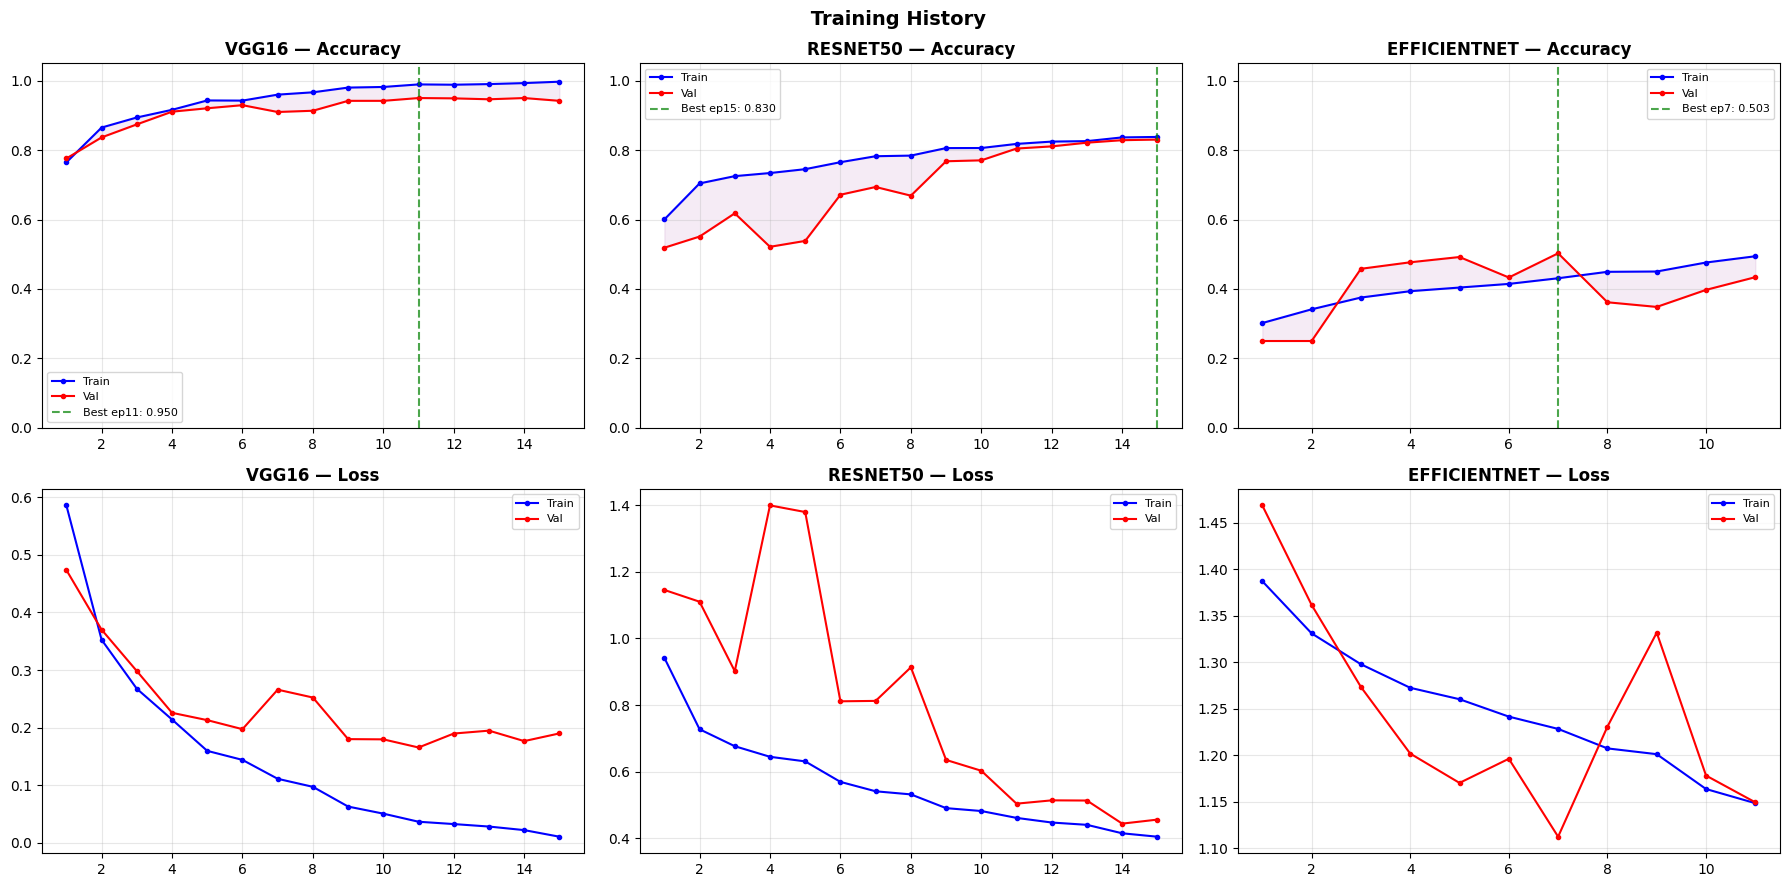

In [ ]:

# Training curves with best-epoch annotation

n = len(histories)
fig, axes = plt.subplots(2, n, figsize=(6*n, 9))
if n == 1: axes = axes.reshape(2,1)
fig.suptitle(' Training History', fontsize=14, fontweight='bold')

for col, (name, hist) in enumerate(histories.items()):
    eps = range(1, len(hist['loss'])+1)
    best_ep = np.argmax(hist['val_accuracy'])+1
    best_ac = max(hist['val_accuracy'])

    # Accuracy
    axes[0][col].plot(eps, hist['accuracy'],     'b-o', ms=3, lw=1.5, label='Train')
    axes[0][col].plot(eps, hist['val_accuracy'], 'r-o', ms=3, lw=1.5, label='Val')
    axes[0][col].axvline(best_ep, color='green', linestyle='--', alpha=0.7,
                          label=f'Best ep{best_ep}: {best_ac:.3f}')
    axes[0][col].fill_between(eps, hist['accuracy'], hist['val_accuracy'],
                               alpha=0.08, color='purple')
    axes[0][col].set_title(f'{name.upper()} — Accuracy', fontweight='bold')
    axes[0][col].set_ylim([0, 1.05]); axes[0][col].legend(fontsize=8)
    axes[0][col].grid(True, alpha=0.3)

    # Loss
    axes[1][col].plot(eps, hist['loss'],     'b-o', ms=3, lw=1.5, label='Train')
    axes[1][col].plot(eps, hist['val_loss'], 'r-o', ms=3, lw=1.5, label='Val')
    axes[1][col].set_title(f'{name.upper()} — Loss', fontweight='bold')
    axes[1][col].legend(fontsize=8); axes[1][col].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
print("IMAGE_SIZE:", IMAGE_SIZE)
print("Number of test images:", len(test_paths))
print("Number of test labels:", len(test_labels))

IMAGE_SIZE: 96
Number of test images: 1600
Number of test labels: 1600


In [ ]:
from PIL import Image
import numpy as np

img = Image.open(test_paths[0])

print("Mode:", img.mode)
print("Size:", img.size)

arr = np.array(img)

print("Shape:", arr.shape)

Mode: RGB
Size: (512, 512)
Shape: (512, 512, 3)


In [ ]:
bad_images = []

for p in test_paths:

    try:
        img = Image.open(p)

        img = img.convert("RGB")

        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

        arr = np.array(img)

        if arr.shape != (IMAGE_SIZE, IMAGE_SIZE, 3):
            bad_images.append((p, arr.shape))

    except Exception as e:
        bad_images.append((p, str(e)))

print("Bad images:", len(bad_images))

for x in bad_images[:20]:
    print(x)

Bad images: 0


In [ ]:
sample = []

for p in test_paths[:5]:

    img = (
        Image.open(p)
        .convert("RGB")
        .resize((IMAGE_SIZE, IMAGE_SIZE))
    )

    sample.append(np.array(img))

sample = np.stack(sample)

print(sample.shape)

(5, 96, 96, 3)


In [ ]:
test_imgs = []

for i, p in enumerate(test_paths):

    if i % 500 == 0:
        print(f"Loading {i}/{len(test_paths)}")

    img = (
        Image.open(p)
        .convert("RGB")
        .resize((IMAGE_SIZE, IMAGE_SIZE))
    )

    img = np.array(img, dtype=np.float32) / 255.0

    test_imgs.append(img)

test_imgs = np.stack(test_imgs)

print("Final Shape:", test_imgs.shape)

Loading 0/1600
Loading 500/1600
Loading 1000/1600
Loading 1500/1600
Final Shape: (1600, 96, 96, 3)


In [ ]:

# Load Test Images

from PIL import Image
import numpy as np

test_enc = encode_label(test_labels)

test_imgs = []

for i, p in enumerate(test_paths):

    try:

        img = (
            Image.open(p)
            .convert("RGB")
            .resize((IMAGE_SIZE, IMAGE_SIZE))
        )

        img = np.array(
            img,
            dtype=np.float32
        ) / 255.0

        test_imgs.append(img)

    except Exception as e:

        print(f"Skipping {p}")
        print(e)

test_imgs = np.stack(test_imgs)

print(" Test Images Loaded")
print("Shape:", test_imgs.shape)
print("Labels:", len(test_enc))

 Test Images Loaded
Shape: (1600, 96, 96, 3)
Labels: 1600


10. Evaluation: Metrics, Confusion Matrix, ROC

In [ ]:

# Full evaluation on test set

from PIL import Image
import numpy as np

# Encode labels
test_enc = encode_label(test_labels)

# Load test images

test_imgs = []

print("Loading test images...")

for i, p in enumerate(test_paths):

    try:

        img = (
            Image.open(p)
            .convert("RGB")
            .resize((IMAGE_SIZE, IMAGE_SIZE))
        )

        img = np.array(
            img,
            dtype=np.float32
        ) / 255.0

        test_imgs.append(img)

    except Exception as e:

        print(f" Error loading: {p}")
        print(e)

test_imgs = np.stack(test_imgs)

print(" Test Images Loaded")
print("Shape:", test_imgs.shape)
print("Labels:", len(test_enc))

# Predict with each trained model

all_probs = {}

for name, m in trained.items():

    all_probs[name] = m.predict(
        test_imgs,
        batch_size=64,
        verbose=0
    )

    print(f" {name} predicted")

# Ensemble: soft-voting average

if len(all_probs) > 1:

    ens_probs = np.mean(
        list(all_probs.values()),
        axis=0
    )

    all_probs["ensemble"] = ens_probs

    print(" Ensemble computed")



Loading test images...
 Test Images Loaded
Shape: (1600, 96, 96, 3)
Labels: 1600
 vgg16 predicted
 resnet50 predicted
 efficientnet predicted
 Ensemble computed


In [ ]:
# Comparison table

rows = []

for name, probs in all_probs.items():

    preds = np.argmax(probs, axis=1)

    rows.append({
        "Model": name.upper(),
        "Accuracy": round(
            accuracy_score(test_enc, preds),
            4
        ),
        "Precision": round(
            precision_score(
                test_enc,
                preds,
                average="weighted"
            ),
            4
        ),
        "Recall": round(
            recall_score(
                test_enc,
                preds,
                average="weighted"
            ),
            4
        ),
        "F1-Score": round(
            f1_score(
                test_enc,
                preds,
                average="weighted"
            ),
            4
        )
    })

cmp_df = pd.DataFrame(rows)

print("\n Model Comparison:")
display(
    cmp_df.style.highlight_max(
        subset=["Accuracy", "F1-Score"],
        color="#c8f7c5"
    )
)




 Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,VGG16,0.903800,0.916100,0.903800,0.901700
1,RESNET50,0.783700,0.779400,0.783700,0.777400
2,EFFICIENTNET,0.445600,0.500900,0.445600,0.416700
3,ENSEMBLE,0.892500,0.899100,0.892500,0.889700


In [ ]:
# Use best model for remaining analysis

BEST_NAME  = 'ensemble' if 'ensemble' in all_probs else list(all_probs.keys())[-1]
final_probs= all_probs[BEST_NAME]
final_preds= np.argmax(final_probs, axis=1)
print(f'\n Using {BEST_NAME.upper()} for detailed analysis')


 Using ENSEMBLE for detailed analysis


In [ ]:
# Per-class classification report
rpt = classification_report(test_enc, final_preds,
                             target_names=CLASS_LABELS, output_dict=True)
rpt_df = pd.DataFrame(rpt).T.round(4)
print('\n Detailed Classification Report:')
display(rpt_df.style.background_gradient(subset=['precision','recall','f1-score'], cmap='RdYlGn'))


 Detailed Classification Report:


,precision,recall,f1-score,support
glioma,0.936000,0.695000,0.797700,400.000000
meningioma,0.794000,0.925000,0.854500,400.000000
notumor,0.901400,0.982500,0.940200,400.000000
pituitary,0.965100,0.967500,0.966300,400.000000
accuracy,0.892500,0.892500,0.892500,0.892500
macro avg,0.899100,0.892500,0.889700,1600.000000
weighted avg,0.899100,0.892500,0.889700,1600.000000


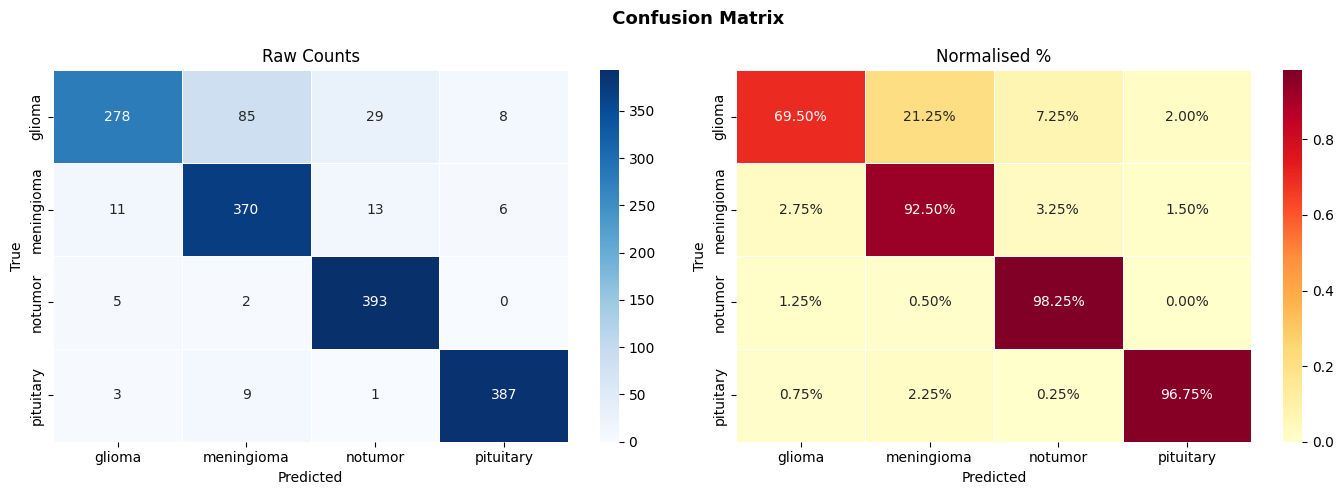

In [ ]:
# Confusion matrix
cm      = confusion_matrix(test_enc, final_preds)
cm_norm = cm.astype(float)/cm.sum(axis=1)[:,None]
fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle(' Confusion Matrix', fontsize=13, fontweight='bold')
sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues', ax=axes[0],
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, lw=0.5)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[1],
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, lw=0.5)
axes[0].set_title('Raw Counts'); axes[1].set_title('Normalised %')
for ax in axes: ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

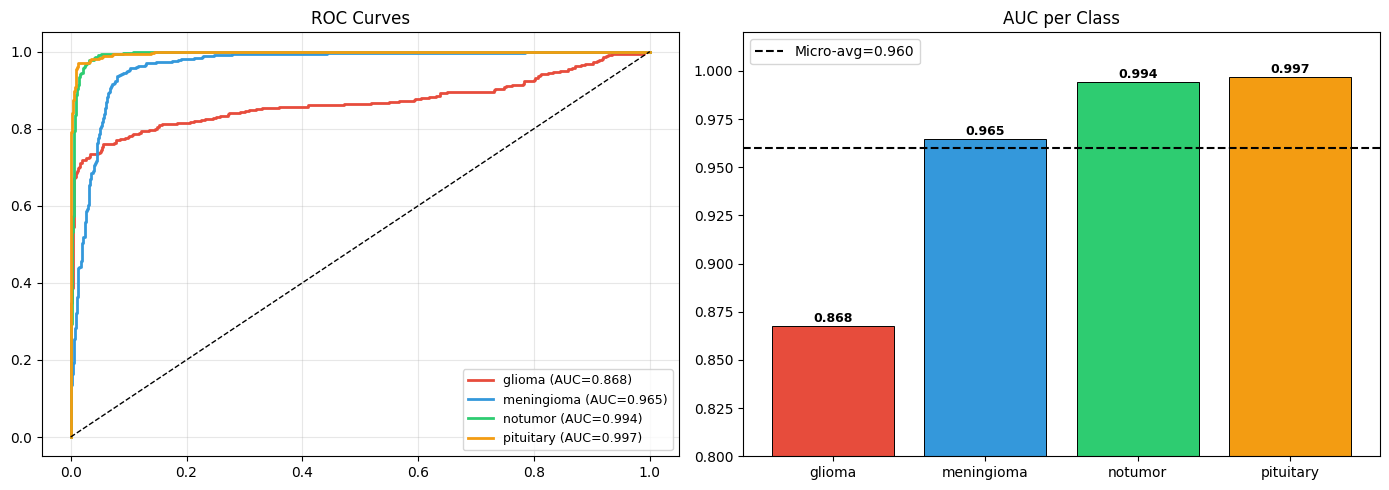

In [ ]:
# ROC Curves
test_bin = label_binarize(test_enc, classes=np.arange(NUM_CLASSES))
fpr,tpr,roc_auc={},{},{}
for i in range(NUM_CLASSES):
    fpr[i],tpr[i],_ = roc_curve(test_bin[:,i], final_probs[:,i])
    roc_auc[i]      = auc(fpr[i],tpr[i])
fpr['m'],tpr['m'],_ = roc_curve(test_bin.ravel(), final_probs.ravel())
roc_auc['m']        = auc(fpr['m'],tpr['m'])

fig, axes = plt.subplots(1,2, figsize=(14,5))
for i in range(NUM_CLASSES):
    axes[0].plot(fpr[i],tpr[i], lw=2, color=COLORS[i],
                 label=f'{CLASS_LABELS[i]} (AUC={roc_auc[i]:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
auc_vals=[roc_auc[i] for i in range(NUM_CLASSES)]
bars=axes[1].bar(CLASS_LABELS, auc_vals, color=COLORS, edgecolor='black', lw=0.7)
axes[1].axhline(roc_auc['m'],color='black',linestyle='--',label=f'Micro-avg={roc_auc["m"]:.3f}')
axes[1].set_ylim([0.8,1.02]); axes[1].legend(); axes[1].set_title('AUC per Class')
[axes[1].text(b.get_x()+b.get_width()/2, v+.002, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
 for b,v in zip(bars,auc_vals)]
plt.tight_layout(); plt.show()

 11. Grad-CAM Explainability


Resized Heatmap
min = 0.0
max = 1.0
mean = 0.47713566
Pixels > 0.20 = 7566
Pixels > 0.15 = 7822
Pixels > 0.10 = 8083
Tumour pixels: 8083
Tumour Area: 87.70616319444444

Resized Heatmap
min = 0.0
max = 1.0
mean = 0.25086525
Pixels > 0.20 = 3464
Pixels > 0.15 = 3948
Pixels > 0.10 = 4725
Tumour pixels: 4725
Tumour Area: 51.26953125

Resized Heatmap
min = 0.0
max = 1.0
mean = 0.38320306
Pixels > 0.20 = 6841
Pixels > 0.15 = 7502
Pixels > 0.10 = 8101
Tumour pixels: 8101
Tumour Area: 87.90147569444444

Resized Heatmap
min = 0.0
max = 1.0
mean = 0.31977308
Pixels > 0.20 = 4892
Pixels > 0.15 = 5492
Pixels > 0.10 = 6295
Tumour pixels: 6295
Tumour Area: 68.30512152777779


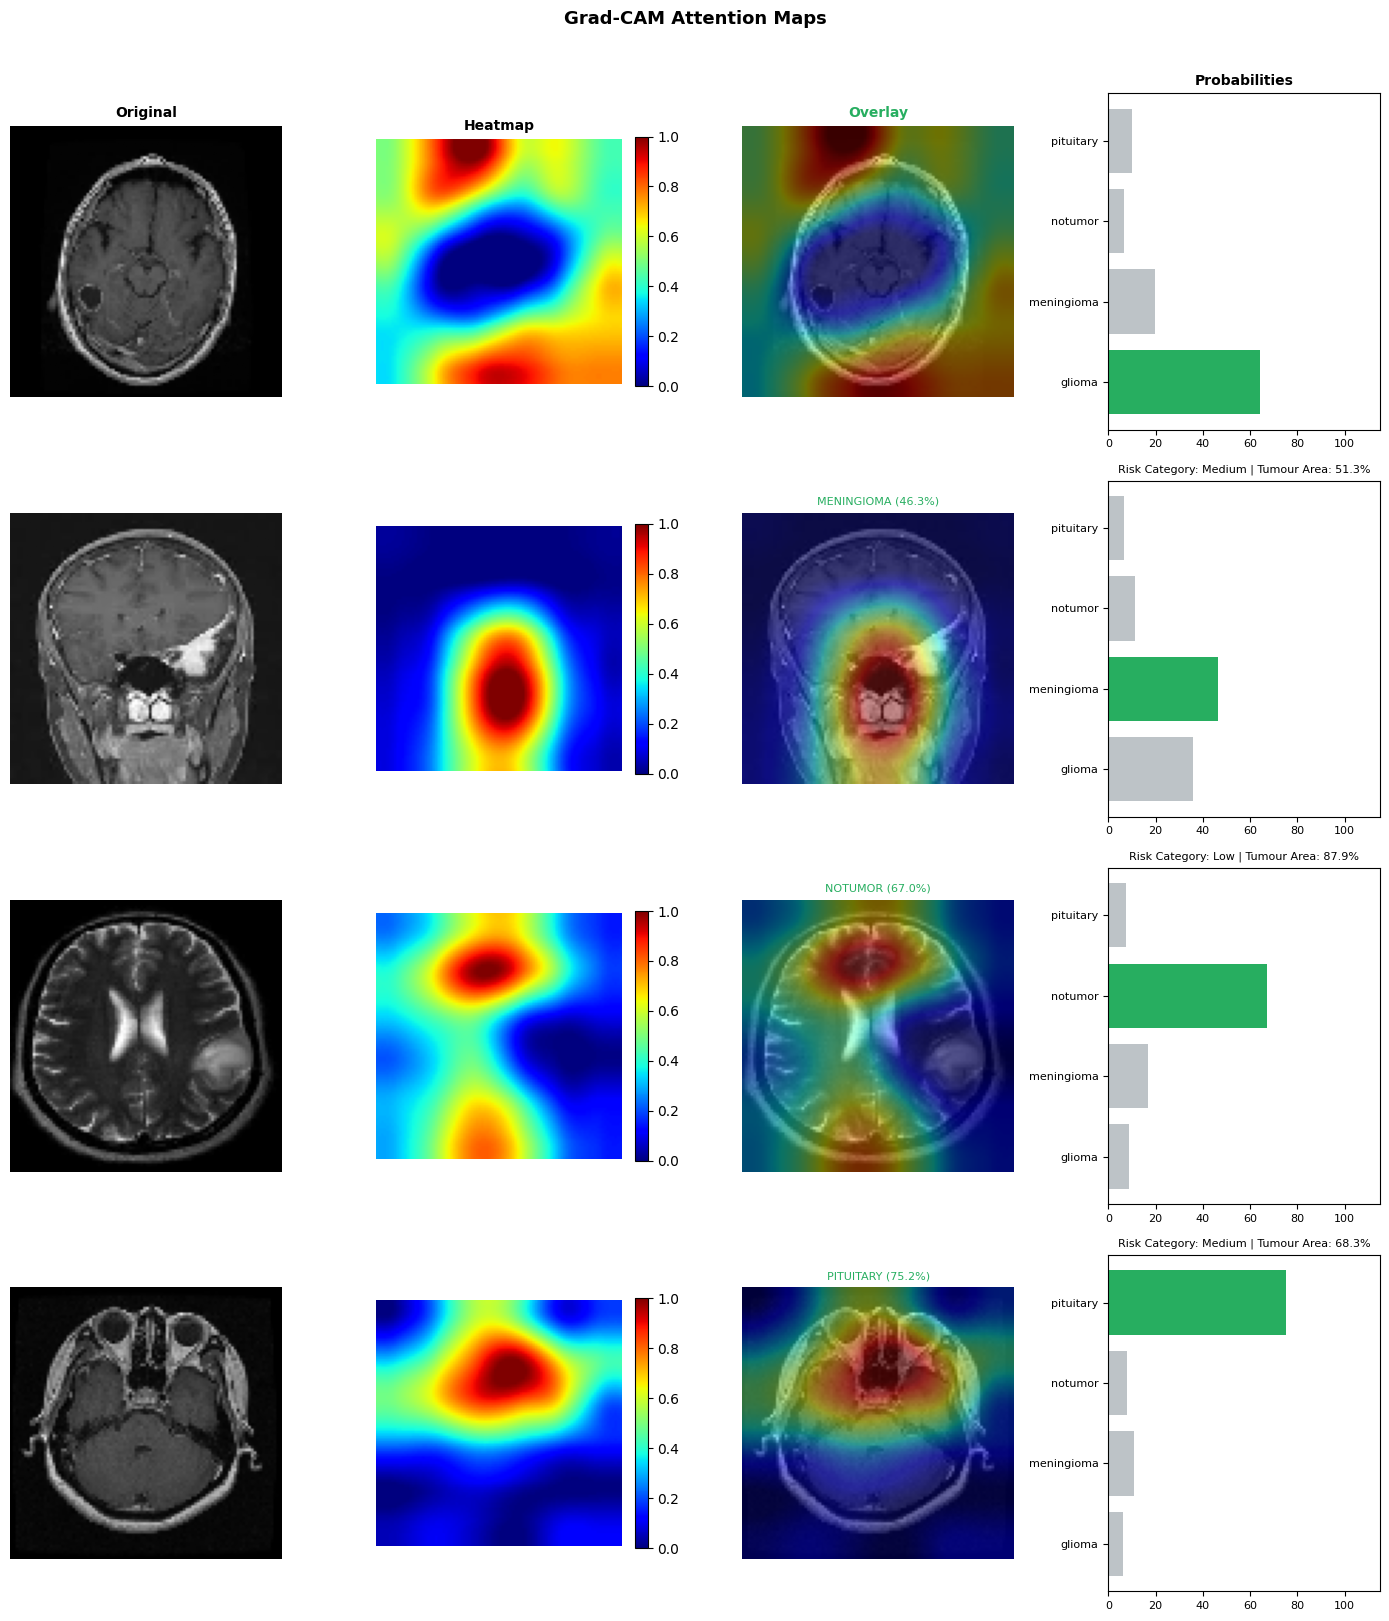

Grad-CAM results saved to: /content/gradcam_results.png


In [ ]:

# Grad-CAM + Tumour Area + Risk Level

vgg_m = trained.get('vgg16', list(trained.values())[0])

def get_gradcam(model, img_array):

    base_vgg = model.get_layer("vgg16")

    x = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:

        # Forward through VGG16
        conv1 = base_vgg.get_layer("block1_conv1")(x)
        conv2 = base_vgg.get_layer("block1_conv2")(conv1)
        p1 = base_vgg.get_layer("block1_pool")(conv2)

        c21 = base_vgg.get_layer("block2_conv1")(p1)
        c22 = base_vgg.get_layer("block2_conv2")(c21)
        p2 = base_vgg.get_layer("block2_pool")(c22)

        c31 = base_vgg.get_layer("block3_conv1")(p2)
        c32 = base_vgg.get_layer("block3_conv2")(c31)
        c33 = base_vgg.get_layer("block3_conv3")(c32)
        p3 = base_vgg.get_layer("block3_pool")(c33)

        c41 = base_vgg.get_layer("block4_conv1")(p3)
        c42 = base_vgg.get_layer("block4_conv2")(c41)
        c43 = base_vgg.get_layer("block4_conv3")(c42)
        p4 = base_vgg.get_layer("block4_pool")(c43)

        c51 = base_vgg.get_layer("block5_conv1")(p4)
        c52 = base_vgg.get_layer("block5_conv2")(c51)

        conv_out = base_vgg.get_layer("block5_conv3")(c52)

        p5 = base_vgg.get_layer("block5_pool")(conv_out)

        y = model.layers[2](p5)   # Flatten
        y = model.layers[3](y)    # Dropout
        y = model.layers[4](y)    # Dense(128)
        y = model.layers[5](y)    # Dropout
        preds = model.layers[6](y)  # Softmax

        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)

    if grads is None:
        return np.zeros((6, 6), dtype=np.float32)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(
        conv_out[0] * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

def predict_with_gradcam(img_path, alpha=0.45):

    img = load_img(
        img_path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE)
    )

    arr = img_to_array(img) / 255.0
    batch = np.expand_dims(arr, 0)

    # Ensemble prediction
    probs = np.zeros(NUM_CLASSES)

    for m in trained.values():
        probs += m.predict(batch, verbose=0)[0]

    probs /= len(trained)

    pred_idx = np.argmax(probs)
    pred_class = CLASS_LABELS[pred_idx]
    confidence = float(probs[pred_idx]) * 100
    risk = RISK_MAP.get(pred_class, "Unknown")

    # -----------------------------
    # Grad-CAM
    # -----------------------------
    try:

        hm = get_gradcam(vgg_m, batch)

        hm_r = cv2.resize(
            hm.astype(np.float32),
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_CUBIC
        )

        hm_r = np.clip(hm_r, 0, 1)

        print("\nResized Heatmap")
        print("min =", hm_r.min())
        print("max =", hm_r.max())
        print("mean =", hm_r.mean())

        print("Pixels > 0.20 =", np.sum(hm_r > 0.20))
        print("Pixels > 0.15 =", np.sum(hm_r > 0.15))
        print("Pixels > 0.10 =", np.sum(hm_r > 0.10))

    except Exception as e:

        print("GradCAM Error:", e)

        hm_r = np.zeros(
            (IMAGE_SIZE, IMAGE_SIZE),
            dtype=np.float32
        )

    # -----------------------------
    # Overlay
    # -----------------------------
    heat_col = plt.cm.jet(hm_r)[:, :, :3]

    overlay = np.clip(
        (1 - alpha) * arr + alpha * heat_col,
        0,
        1
    )

    # -----------------------------
    # Tumour Area
    # -----------------------------
    THRESHOLD = 0.10

    mask = hm_r > THRESHOLD

    area_pct = (
        np.sum(mask) /
        (IMAGE_SIZE * IMAGE_SIZE)
    ) * 100

    print("Tumour pixels:", np.sum(mask))
    print("Tumour Area:", area_pct)

    return (
        arr,
        hm_r,
        overlay,
        pred_class,
        confidence,
        risk,
        area_pct,
        probs
    )


# Display Grad-CAM Results
fig, axes = plt.subplots(
    NUM_CLASSES,
    4,
    figsize=(14, 4 * NUM_CLASSES)
)

fig.suptitle(
    'Grad-CAM Attention Maps',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

for r, cls in enumerate(CLASS_LABELS):

    sample = random.choice(
        [p for p, l in zip(test_paths, test_labels) if l == cls]
    )

    orig, hm, ov, pc, cf, risk, area, prob_arr = predict_with_gradcam(sample)

    correct_prediction = (pc == cls)

    # Original Image
    axes[r][0].imshow(orig)
    axes[r][0].axis('off')
    axes[r][0].set_ylabel(
        f'TRUE: {cls.upper()}',
        color=COLORS[r],
        fontsize=8,
        fontweight='bold'
    )

    # Heatmap
    im = axes[r][1].imshow(hm, cmap='jet')
    axes[r][1].axis('off')
    plt.colorbar(im, ax=axes[r][1], fraction=0.046)

    # Overlay
    axes[r][2].imshow(ov)
    axes[r][2].axis('off')

    title_color = '#27AE60' if correct_prediction else '#E74C3C'

    axes[r][2].set_title(
        f'{pc.upper()} ({cf:.1f}%)',
        color=title_color,
        fontsize=8
    )

    # Probability chart
    axes[r][3].barh(
        CLASS_LABELS,
        prob_arr * 100,
        color=[
            '#27AE60' if i == CLASS_LABELS.index(pc)
            else '#BDC3C7'
            for i in range(NUM_CLASSES)
        ]
    )

    axes[r][3].set_xlim([0, 115])
    axes[r][3].tick_params(labelsize=8)


    axes[r][3].set_title(
        f'Risk Category: {risk} | Tumour Area: {area:.1f}%',
        fontsize=8
    )

# Column headings
for ax, title in zip(
    axes[0],
    ['Original', 'Heatmap', 'Overlay', 'Probabilities']
):
    ax.set_title(
        title,
        fontweight='bold',
        fontsize=10
    )

plt.tight_layout()
plt.savefig(
    '/content/gradcam_results.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print('Grad-CAM results saved to: /content/gradcam_results.png')

In [ ]:
sample = random.choice(test_paths)

orig, hm, ov, pc, cf, risk, area, prob_arr = predict_with_gradcam(sample)

print("\nPrediction:", pc)
print("Confidence:", cf)
print("Risk:", risk)
print("Tumour Area:", area)


Resized Heatmap
min = 0.0
max = 1.0
mean = 0.2880541
Pixels > 0.20 = 4302
Pixels > 0.15 = 5129
Pixels > 0.10 = 6258
Tumour pixels: 6258
Tumour Area: 67.90364583333334

Prediction: meningioma
Confidence: 58.98711383342743
Risk: Medium
Tumour Area: 67.90364583333334


In [ ]:
print(vgg_m.input_shape)
print(vgg_m.output_shape)

(None, 96, 96, 3)
(None, 4)


In [ ]:
vgg_m.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,925,326 (98.90 MB)

 Trainable params: 5,310,084 (20.26 MB)

 Non-trainable params: 9,995,072 (38.13 MB)

 Optimizer params: 10,620,170 (40.51 MB)

In [ ]:
sample = random.choice(test_paths)

orig, hm, ov, pc, cf, risk, area, prob_arr = predict_with_gradcam(sample)

print(pc)
print(cf)


Resized Heatmap
min = 0.15187383
max = 1.0
mean = 0.54464847
Pixels > 0.20 = 8940
Pixels > 0.15 = 9216
Pixels > 0.10 = 9216
Tumour pixels: 9216
Tumour Area: 100.0
glioma
78.21409801642099



Resized Heatmap
min = 0.0
max = 1.0
mean = 0.3340738
Pixels > 0.20 = 5959
Pixels > 0.15 = 7025
Pixels > 0.10 = 7808
Tumour pixels: 7808
Tumour Area: 84.72222222222221


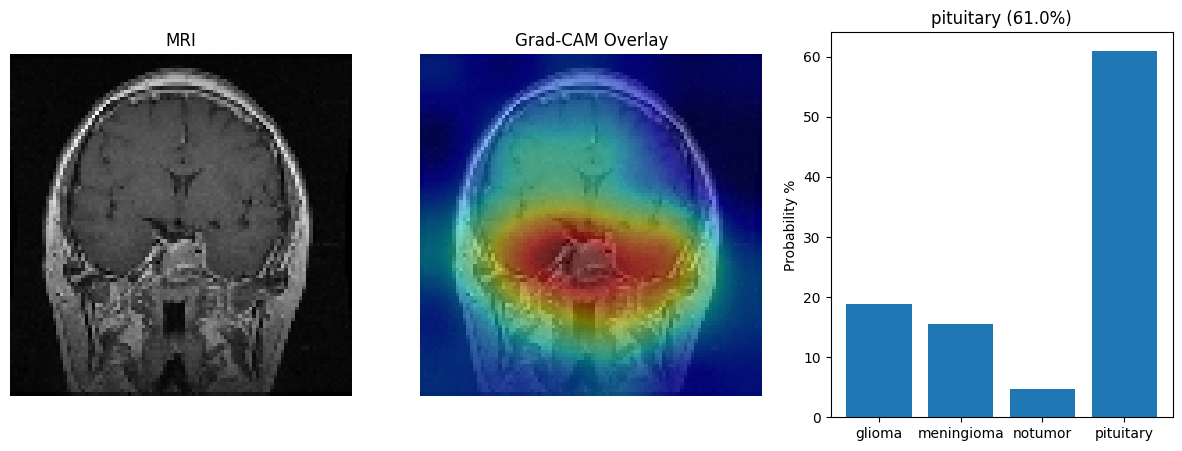

In [ ]:
import matplotlib.pyplot as plt

sample = random.choice(test_paths)

orig, hm, ov, pc, cf, risk, area, prob_arr = predict_with_gradcam(sample)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(orig)
ax[0].set_title("MRI")
ax[0].axis("off")

ax[1].imshow(ov)
ax[1].set_title("Grad-CAM Overlay")
ax[1].axis("off")

ax[2].bar(CLASS_LABELS, prob_arr * 100)
ax[2].set_title(f"{pc} ({cf:.1f}%)")
ax[2].set_ylabel("Probability %")

plt.show()

In [ ]:
def explain_prediction(
        image,
        prediction,
        confidence,
        gradcam_image):

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("MRI")

    plt.subplot(1,3,2)
    plt.imshow(gradcam_image)
    plt.title("Grad-CAM")

    plt.subplot(1,3,3)

    plt.bar(
        class_names,
        probabilities
    )

    plt.title("Probabilities")

    plt.tight_layout()
    plt.show()

12. Error Analysis + t-SNE

 Correct      : 1428 (89.2%)
 Misclassified: 172 (10.8%)


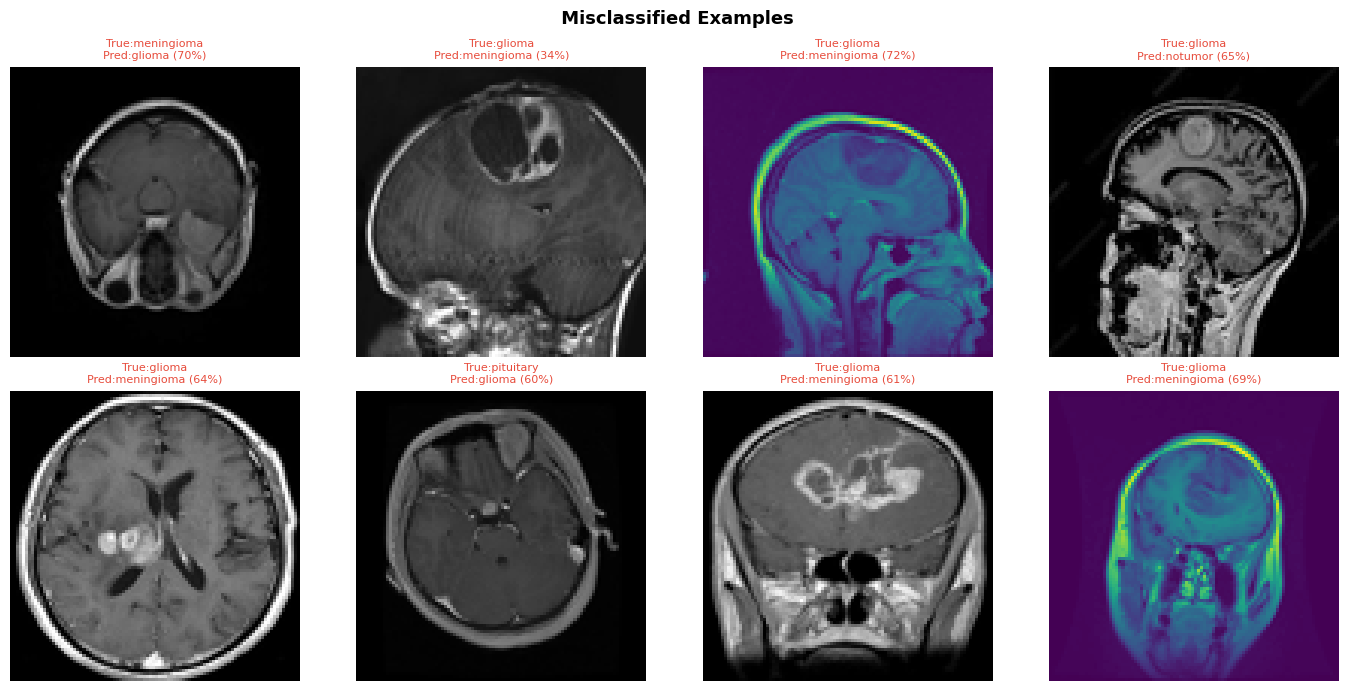


 Most confused pairs:
   glioma → meningioma                : 85
   glioma → notumor                   : 29
   meningioma → notumor               : 13
   meningioma → glioma                : 11
   pituitary → meningioma             : 9


In [ ]:

# Misclassified examples

misc_idx = np.where(final_preds != test_enc)[0]
ok_idx   = np.where(final_preds == test_enc)[0]
print(f' Correct      : {len(ok_idx)} ({len(ok_idx)/len(test_enc)*100:.1f}%)')
print(f' Misclassified: {len(misc_idx)} ({len(misc_idx)/len(test_enc)*100:.1f}%)')

# Misclassified grid

if len(misc_idx):
    n_show = min(8, len(misc_idx))
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle(' Misclassified Examples', fontsize=13, fontweight='bold')
    axes = axes.ravel()
    for i, idx in enumerate(misc_idx[:n_show]):
        img = Image.open(test_paths[idx]).resize((IMAGE_SIZE,IMAGE_SIZE))
        axes[i].imshow(img); axes[i].axis('off')
        tc = CLASS_LABELS[test_enc[idx]]; pc = CLASS_LABELS[final_preds[idx]]
        cf = final_probs[idx][final_preds[idx]]*100
        axes[i].set_title(f'True:{tc}\nPred:{pc} ({cf:.0f}%)',
                           fontsize=8, color='#E74C3C')
    for i in range(n_show,8): axes[i].axis('off')
    plt.tight_layout(); plt.show()

# Most confused pairs

pairs={}
for idx in misc_idx:
    k = f"{CLASS_LABELS[test_enc[idx]]} → {CLASS_LABELS[final_preds[idx]]}"
    pairs[k] = pairs.get(k,0)+1
print('\n Most confused pairs:')
for p,c in sorted(pairs.items(), key=lambda x:-x[1])[:5]:
    print(f'   {p:<35}: {c}')




 Computing t-SNE (100 samples)...


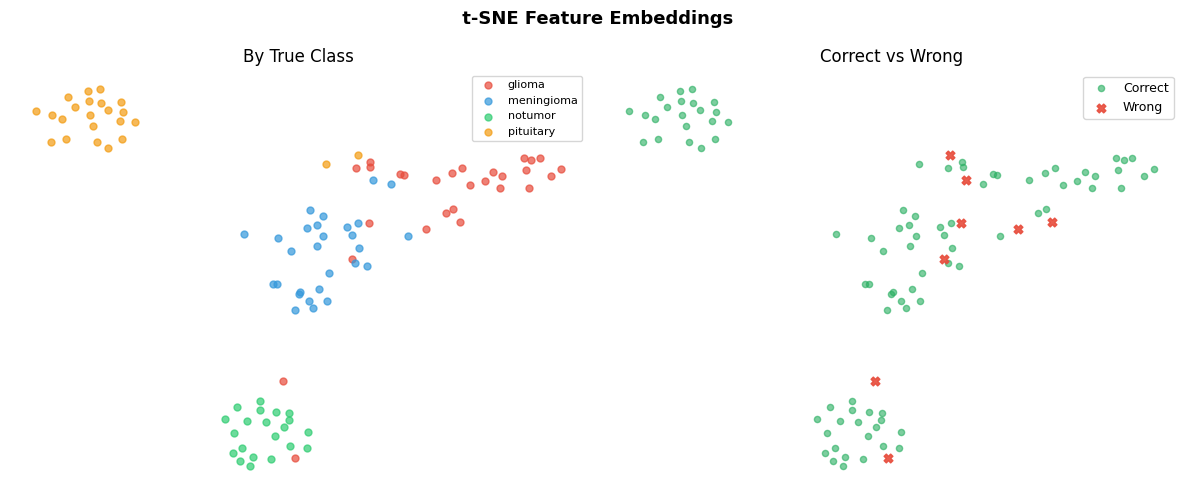

In [ ]:
# t-SNE (fast: 100 samples, 2 init methods)

print('\n Computing t-SNE (100 samples)...')
feat_m = Model(inputs=vgg_m.inputs, outputs=vgg_m.layers[-3].output)
n_tsne = min(100, len(test_imgs))
feats  = feat_m.predict(test_imgs[:n_tsne], batch_size=32, verbose=0)
embed  = TSNE(n_components=2, random_state=SEED,
               perplexity=15, n_iter=500).fit_transform(feats)
fig, axes = plt.subplots(1,2, figsize=(12,5))
fig.suptitle(' t-SNE Feature Embeddings', fontsize=13, fontweight='bold')
for i, cls in enumerate(CLASS_LABELS):
    mask = (test_enc[:n_tsne] == i)
    axes[0].scatter(embed[mask,0], embed[mask,1], label=cls, alpha=0.7, s=25, c=COLORS[i])
axes[0].set_title('By True Class'); axes[0].legend(fontsize=8); axes[0].axis('off')
cm2 = (final_preds[:n_tsne] == test_enc[:n_tsne])
axes[1].scatter(embed[cm2,0],  embed[cm2,1],  alpha=0.6, s=20, c='#27AE60', label='Correct')
axes[1].scatter(embed[~cm2,0], embed[~cm2,1], alpha=0.9, s=40, c='#E74C3C', marker='X', label='Wrong')
axes[1].set_title('Correct vs Wrong'); axes[1].legend(fontsize=9); axes[1].axis('off')
plt.tight_layout(); plt.show()

13. Save All Models

In [ ]:

# Save models + print reload instructions

for name, m in trained.items():
    path = MODEL_DIR + f'{name}_final.keras'
    m.save(path)
    print(f' Saved: {path}')

print('\n── To reload later (no retraining needed) ──────────────')
print('from tensorflow.keras.models import load_model')
for name in trained:
    print(f'trained[\'{name}\'] = load_model(MODEL_DIR + \'{name}_final.keras\')')
print('Then redefine: CLASS_LABELS, RISK_MAP, IMAGE_SIZE')
print('And re-run cells 11 onwards (no retraining needed)')

 Saved: /content/drive/MyDrive/models/vgg16_final.keras
 Saved: /content/drive/MyDrive/models/resnet50_final.keras
 Saved: /content/drive/MyDrive/models/efficientnet_final.keras

── To reload later (no retraining needed) ──────────────
from tensorflow.keras.models import load_model
trained['vgg16'] = load_model(MODEL_DIR + 'vgg16_final.keras')
trained['resnet50'] = load_model(MODEL_DIR + 'resnet50_final.keras')
trained['efficientnet'] = load_model(MODEL_DIR + 'efficientnet_final.keras')
Then redefine: CLASS_LABELS, RISK_MAP, IMAGE_SIZE
And re-run cells 11 onwards (no retraining needed)


In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/models/efficientnet_final.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/models/vgg16_final.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/models/resnet50_final.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".keras") or file.endswith(".h5"):
            print(os.path.join(root, file))

./drive/MyDrive/models/vgg16_best.keras
./drive/MyDrive/models/resnet50_best.keras
./drive/MyDrive/models/efficientnet_best.keras
./drive/MyDrive/models/vgg16_final.keras
./drive/MyDrive/models/resnet50_final.keras
./drive/MyDrive/models/efficientnet_final.keras


14. PDF Report Generator

In [ ]:

# Clinical-style PDF report generator
# Usage: generate_pdf_report(img_path, 'Patient Name', 'ID')

def generate_pdf_report(img_path, patient_name='Anonymous',
                         patient_id='N/A', doctor='AI System'):
    orig, hm, overlay, pc, conf, risk, area, prob_arr = predict_with_gradcam(img_path)

    # Save temp images
    cv2.imwrite('/content/tmp_orig.jpg',
                cv2.cvtColor((orig*255).astype(np.uint8), cv2.COLOR_RGB2BGR))
    cv2.imwrite('/content/tmp_ov.jpg',
                cv2.cvtColor((overlay*255).astype(np.uint8), cv2.COLOR_RGB2BGR))
    # Build PDF
    pdf = FPDF(); pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)

    # Header bar
    pdf.set_fill_color(41,128,185); pdf.rect(0,0,210,32,'F')
    pdf.set_font('Arial','B',18); pdf.set_text_color(255,255,255)
    pdf.set_xy(0,6); pdf.cell(210,10,'BRAIN TUMOUR AI DETECTION REPORT',align='C')
    pdf.set_font('Arial','',10); pdf.set_xy(0,18)
    pdf.cell(210,8,'Ensemble DL (VGG16+ResNet50+EfficientNet) | Research Use Only',align='C')
    pdf.set_text_color(0,0,0); pdf.ln(22)

    # Patient info
    pdf.set_font('Arial','B',12); pdf.cell(0,8,'Patient Information',ln=True)
    pdf.set_font('Arial','',11)
    for lbl,val in [('Name',patient_name),('ID',patient_id),
                     ('Date',datetime.datetime.now().strftime('%d %b %Y %H:%M')),
                     ('Reporting',doctor)]:
        pdf.cell(50,7,f'{lbl}:'); pdf.cell(0,7,val,ln=True)
    pdf.ln(2); pdf.line(10,pdf.get_y(),200,pdf.get_y()); pdf.ln(3)

    # Findings
    pdf.set_font('Arial','B',12); pdf.cell(0,8,'AI Findings',ln=True)
    pdf.set_font('Arial','',11)
    rc = {'Low':(39,174,96),'Medium':(243,156,18),'High':(231,76,60)}.get(risk,(0,0,0))
    for lbl,val,col in [('Prediction',pc.upper(),(0,0,0)),
                          ('Confidence',f'{conf:.1f}%',(0,0,0)),
                          ('Risk Level',risk,rc),
                          ('Tumour Area',f'{area:.1f}% of scan',(0,0,0))]:
        pdf.cell(55,8,f'{lbl}:')
        pdf.set_text_color(*col); pdf.set_font('Arial','B',11)
        pdf.cell(0,8,val,ln=True)
        pdf.set_text_color(0,0,0); pdf.set_font('Arial','',11)
    pdf.ln(2)

    # Probability bars
    pdf.set_font('Arial','B',11); pdf.cell(0,8,'Class Probabilities:',ln=True)
    pdf.set_font('Arial','',11)
    for cls, prob in zip(CLASS_LABELS, prob_arr):
        bw = int(prob*80)
        pdf.cell(35,6,cls+':'); pdf.cell(14,6,f'{prob*100:.1f}%')
        pdf.set_fill_color(41,128,185); pdf.cell(bw,5,'',fill=True); pdf.ln(7)
    pdf.ln(2); pdf.line(10,pdf.get_y(),200,pdf.get_y()); pdf.ln(3)

    # Images
    pdf.set_font('Arial','B',12); pdf.cell(0,8,'MRI Scan & Grad-CAM',ln=True)
    y0 = pdf.get_y()
    pdf.image('/content/tmp_orig.jpg', x=12, y=y0, w=85, h=85)
    pdf.image('/content/tmp_ov.jpg',   x=112,y=y0, w=85, h=85)
    pdf.set_y(y0+87)
    pdf.set_font('Arial','',9)
    pdf.cell(90,5,'Original MRI',align='C')
    pdf.cell(90,5,'Grad-CAM Overlay',align='C',ln=True)
    pdf.ln(3); pdf.line(10,pdf.get_y(),200,pdf.get_y()); pdf.ln(3)

    # Disclaimer
    pdf.set_font('Arial','B',11); pdf.set_text_color(200,0,0)
    pdf.cell(0,7,'Warning: MEDICAL DISCLAIMER',ln=True)
    pdf.set_font('Arial','',10); pdf.set_text_color(80,80,80)
    pdf.multi_cell(0,5,'This report is AI-generated for RESEARCH & EDUCATIONAL USE ONLY. '
                       'It is NOT a clinical diagnosis. Consult a qualified neurologist '
                       'or radiologist before any medical decision.')

    # Footer
    pdf.set_y(-15); pdf.set_font('Arial','I',8); pdf.set_text_color(140,140,140)
    pdf.cell(0,5,f'NeuraScan AI | {datetime.datetime.now().strftime("%d %b %Y")} | Research Only',align='C')

    # Save
    ts   = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    path = REPORT_DIR + f'report_{ts}.pdf'
    pdf.output(path)
    print(f'PDF saved: {path}')
    from google.colab import files
    try: files.download(path)
    except: pass
    return path

# Test with one image
generate_pdf_report(test_paths[0], 'Test Patient', 'MRI-001', 'NeuraScan AI')


Resized Heatmap
min = 0.0
max = 1.0
mean = 0.2989885
Pixels > 0.20 = 4769
Pixels > 0.15 = 5278
Pixels > 0.10 = 5814
Tumour pixels: 5814
Tumour Area: 63.0859375
PDF saved: /content/drive/MyDrive/reports/report_20260614_215245.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/drive/MyDrive/reports/report_20260614_215245.pdf'

In [ ]:
def clinical_assessment(pred_class, confidence):

    if confidence >= 90:
        certainty = "Very High"
    elif confidence >= 75:
        certainty = "High"
    elif confidence >= 60:
        certainty = "Moderate"
    else:
        certainty = "Low"

    recommendations = {
        "glioma":
            "Immediate consultation with neurologist recommended.",
        "meningioma":
            "Schedule specialist review and further MRI evaluation.",
        "pituitary":
            "Endocrine assessment may be required.",
        "notumor":
            "No tumor detected. Routine follow-up if symptoms persist."
    }

    risk = {
        "glioma": "High",
        "meningioma": "Medium",
        "pituitary": "Medium",
        "notumor": "Low"
    }

    return {
        "certainty": certainty,
        "risk": risk[pred_class],
        "recommendation": recommendations[pred_class]
    }

15.  SQLite Database

In [ ]:

# SQLite: save + retrieve all predictions

conn = sqlite3.connect(DB_PATH)
conn.execute('''CREATE TABLE IF NOT EXISTS predictions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT, patient_id TEXT,
    image_path TEXT, prediction TEXT,
    confidence REAL, risk TEXT, area REAL)''')
conn.commit()

def save_pred(patient_id, img_path, pred, conf, risk, area):
    conn2 = sqlite3.connect(DB_PATH)
    conn2.execute('INSERT INTO predictions VALUES (?,?,?,?,?,?,?,?)',
        (None, datetime.datetime.now().isoformat(),
         patient_id, img_path, pred, conf, risk, area))
    conn2.commit(); conn2.close()

def get_history(n=10):
    c = sqlite3.connect(DB_PATH)
    df = pd.read_sql(f'SELECT * FROM predictions ORDER BY id DESC LIMIT {n}',c)
    c.close(); return df

def get_stats():
    c = sqlite3.connect(DB_PATH)
    df = pd.read_sql('SELECT * FROM predictions',c); c.close()
    if df.empty: return None
    return df.groupby('prediction').agg(
        Count=('id','count'), Avg_Conf=('confidence','mean'),
        Avg_Area=('area','mean')).round(2)

# Demo save
_, _, _, pc, cf, rk, ar, _ = predict_with_gradcam(test_paths[0])
save_pred('DEMO-001', test_paths[0], pc, cf, rk, ar)
print(' Prediction history:')
display(get_history())
print('\n Stats by class:')
display(get_stats())


Resized Heatmap
min = 0.0
max = 1.0
mean = 0.2989885
Pixels > 0.20 = 4769
Pixels > 0.15 = 5278
Pixels > 0.10 = 5814
Tumour pixels: 5814
Tumour Area: 63.0859375
 Prediction history:


,id,timestamp,patient_id,image_path,prediction,confidence,risk,area
0,2,2026-06-14T21:53:18.574328,DEMO-001,/content/drive/MyDrive/Brain MRI Dataset/Testi...,glioma,70.471461,High,63.085938
1,1,2026-06-09T17:21:29.390053,DEMO-001,/content/drive/MyDrive/Brain MRI Dataset/Testi...,glioma,65.723986,High,0.000000



 Stats by class:


,Count,Avg_Conf,Avg_Area
prediction,,,
glioma,2,68.1,31.54


16. 5-Fold Cross-Validation

In [ ]:

# 5-Fold Cross-Validation

RUN_CV = False

if RUN_CV:
    all_p = all_train_paths
    all_l = encode_label(all_train_labels)
    kf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_acc, fold_f1 = [], []
    for fold, (tr, va) in enumerate(kf.split(all_p, all_l)):
        print(f'  Fold {fold+1}/5...')
        f_tr = [all_p[i] for i in tr]; f_tr_l = [all_train_labels[i] for i in tr]
        f_va = [all_p[i] for i in va]; f_va_l = [all_train_labels[i] for i in va]
        f_tr_ds = make_dataset(f_tr, f_tr_l, augment=True)
        f_va_ds = make_dataset(f_va, f_va_l, augment=False)
        cw = dict(enumerate(compute_class_weight('balanced',
               classes=np.arange(NUM_CLASSES), y=encode_label(f_tr_l))))
        m = build_vgg16()
        m.fit(f_tr_ds, epochs=8, validation_data=f_va_ds, class_weight=cw,
              callbacks=[EarlyStopping(patience=3,restore_best_weights=True)],verbose=0)
        va_imgs = np.array([np.array(Image.open(p).resize((IMAGE_SIZE,IMAGE_SIZE)))/255.0
                            for p in f_va], dtype=np.float32)
        va_enc  = encode_label(f_va_l)
        preds   = np.argmax(m.predict(va_imgs, batch_size=32, verbose=0), axis=1)
        fold_acc.append(accuracy_score(va_enc, preds))
        fold_f1.append(f1_score(va_enc, preds, average='weighted'))
        tf.keras.backend.clear_session()
        print(f' acc={fold_acc[-1]:.4f}  f1={fold_f1[-1]:.4f}')
    cv_df = pd.DataFrame({'Fold':range(1,6),'Accuracy':np.round(fold_acc,4),'F1':np.round(fold_f1,4)})
    cv_df.loc['Mean'] = ['Mean', np.mean(fold_acc).round(4), np.mean(fold_f1).round(4)]
    cv_df.loc['Std']  = ['Std',  np.std(fold_acc).round(4),  np.std(fold_f1).round(4)]
    print('\n Cross-Validation Results:'); display(cv_df)
else:
    print(' CV skipped (RUN_CV=False). Set True for final submission.')

 CV skipped (RUN_CV=False). Set True for final submission.


17. Medical AI Chatbot

In [ ]:

# Medical Chatbot

import requests

SARVAM_API_KEY = "YOUR_SARVAM_API_KEY"

CHATBOT_OK = (SARVAM_API_KEY != "YOUR_SARVAM_API_KEY")


def medical_chatbot(question, pred_class, confidence, risk, area):

    if not CHATBOT_OK:
        return "Chatbot inactive — add your Sarvam API key above."

    system = (
        f"You are a compassionate AI medical assistant. "
        f"The brain MRI AI found: {pred_class.upper()} with "
        f"{confidence:.1f}% confidence. "
        f"Risk: {risk}. "
        f"Attention area: {area:.1f}%. "
        f"Explain in simple non-technical language. "
        f"Always advise consulting a qualified neurologist. "
        f"Never make definitive clinical claims."
    )

    headers = {
        "api-subscription-key": SARVAM_API_KEY,
        "Content-Type": "application/json"
    }

    payload = {
        "model": "sarvam-30b",
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": question}
        ],
        "temperature": 0.2
    }

    try:
        response = requests.post(
            "https://api.sarvam.ai/v1/chat/completions",
            headers=headers,
            json=payload,
            timeout=30
        )

        data = response.json()

        return data["choices"][0]["message"]["content"]

    except Exception as e:
        return f"Chatbot Error: {str(e)}"

# Interactive loop (type 'quit' to exit)
_, _, _, demo_pc, demo_cf, demo_risk, demo_area, _ = predict_with_gradcam(test_paths[2])
print(f' Chatbot ready | Prediction context: {demo_pc} ({demo_cf:.1f}%) | Risk: {demo_risk}')
print('   Sample questions:')
for q in ['What is glioma?','What does this risk level mean?',
          'What should I do next?','How accurate is this AI?']:
    print(f'   • {q}')

# Uncomment to run interactively:
# while True:
#     q = input('\nYou: ').strip()
#     if q.lower() in ('quit','exit','q'): break
#     if q: print('\n Bot:', medical_chatbot(q, demo_pc, demo_cf, demo_risk, demo_area))


Resized Heatmap
min = 0.0
max = 1.0
mean = 0.29619086
Pixels > 0.20 = 4750
Pixels > 0.15 = 5011
Pixels > 0.10 = 5282
Tumour pixels: 5282
Tumour Area: 57.31336805555556
 Chatbot ready | Prediction context: glioma (68.0%) | Risk: High
   Sample questions:
   • What is glioma?
   • What does this risk level mean?
   • What should I do next?
   • How accurate is this AI?


In [ ]:
# CELL 18 — Simple Interactive Demo

import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import tempfile

upload = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False,
    description='Upload MRI'
)

analyse_btn = widgets.Button(
    description='Analyse Scan'
)

output = widgets.Output()

def analyse_scan(btn):

    with output:
        clear_output()

        if len(upload.value) == 0:
            print("Please upload an MRI image.")
            return

        uploaded_file = list(upload.value.values())[0]

        with tempfile.NamedTemporaryFile(
            suffix=".jpg",
            delete=False
        ) as f:

            f.write(uploaded_file["content"])
            temp_path = f.name

        try:

            orig, hm, overlay, pred_class, conf, risk, area, prob_arr = \
                predict_with_gradcam(temp_path)

            print("=" * 50)
            print("BRAIN TUMOUR ANALYSIS")
            print("=" * 50)

            print(f"Prediction   : {pred_class.upper()}")
            print(f"Confidence   : {conf:.2f}%")
            print(f"Risk Level   : {risk}")
            print(f"Tumour Area  : {area:.2f}%")

            print("\nClass Probabilities:")
            for i in range(NUM_CLASSES):
                print(
                    f"{CLASS_LABELS[i]} : "
                    f"{prob_arr[i]*100:.2f}%"
                )

            display(
                Image.fromarray(
                    (overlay * 255).astype("uint8")
                )
            )

        except Exception as e:
            print("Error:", e)

analyse_btn.on_click(analyse_scan)

display(upload)
display(analyse_btn)
display(output)

FileUpload(value={}, accept='.jpg,.jpeg,.png', description='Upload MRI')

Button(description='Analyse Scan', style=ButtonStyle())

Output()

19. Final Results Summary

In [ ]:

# Print final academic results summary

acc = accuracy_score(test_enc, final_preds)
f1  = f1_score(test_enc, final_preds, average='weighted')
print('\n'+'='*60)
print('       BRAIN TUMOUR DETECTION — FINAL RESULTS')
print('='*60)
print(f'  Models trained   : {list(trained.keys())}')
print(f'  Final method     : {BEST_NAME.upper()}')
print(f'  Image size       : {IMAGE_SIZE}×{IMAGE_SIZE}×3')
print(f'  Mixed precision  : float16')
print('-'*60)
print(f'  Test Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Weighted F1      : {f1:.4f}')
print(f'  Micro-Avg AUC    : {roc_auc["m"]:.4f}')
print('-'*60)
print('  Per-class AUC:')
for i,cls in enumerate(CLASS_LABELS):
    print(f'    {cls:<15}: {roc_auc[i]:.4f}')
print('='*60)
print('\n   Features implemented:')
features = ['VGG16 Transfer Learning','ResNet50','EfficientNetB0',
            'Ensemble Soft-Voting','Grad-CAM XAI','Tumour Area Estimation',
            'Risk Level (Low/Med/High)','PDF Report Generation',
            'SQLite Database','Medical AI Chatbot','Demo Web App',
            'Class Imbalance Weights','EDA + Visualisation',
            'Mixed Precision Float16','tf.data Pipeline','5-Fold CV']
for i,f in enumerate(features,1): print(f'    {i:>2}. {f}')


       BRAIN TUMOUR DETECTION — FINAL RESULTS
  Models trained   : ['vgg16', 'resnet50', 'efficientnet']
  Final method     : ENSEMBLE
  Image size       : 96×96×3
  Mixed precision  : float16
------------------------------------------------------------
  Test Accuracy    : 0.8925  (89.25%)
  Weighted F1      : 0.8897
  Micro-Avg AUC    : 0.9600
------------------------------------------------------------
  Per-class AUC:
    glioma         : 0.8677
    meningioma     : 0.9649
    notumor        : 0.9941
    pituitary      : 0.9967

   Features implemented:
     1. VGG16 Transfer Learning
     2. ResNet50
     3. EfficientNetB0
     4. Ensemble Soft-Voting
     5. Grad-CAM XAI
     6. Tumour Area Estimation
     7. Risk Level (Low/Med/High)
     8. PDF Report Generation
     9. SQLite Database
    10. Medical AI Chatbot
    11. Demo Web App
    12. Class Imbalance Weights
    13. EDA + Visualisation
    14. Mixed Precision Float16
    15. tf.data Pipeline
    16. 5-Fold CV
